# Week 6 Student Worksheet: Spatial Prediction Shootout

## Traditional Stats vs. Machine Learning: Filling the Gaps

> *"Kriging tells you where it's uncertain. ML just says 'trust me.'"*

### Today's Mission

Transform Week 5's discrete rainfall stations into **continuous rainfall surfaces** using **two fundamentally different approaches**:

1. **Kriging (Statistical)** — uses spatial correlation + provides uncertainty
2. **Random Forest (ML)** — uses data patterns + easily adds features

Then compare them head-to-head with two simpler methods (Nearest Neighbor, IDW) and determine which gives the Commander more actionable intelligence.

> Fill in the code cells marked with `# YOUR CODE HERE`. Use AI tools strategically — but understand every line you write.

In [ ]:
# Install required packages (run once)
%pip install pykrige scikit-learn rasterio rasterstats 

---

## Cell [1]: Environment Setup & Data Loading (Slide 2)

Load the Fung-wong typhoon data and filter to the study area. Reuse your Week 5 `parse_rainfall_json()` function.

**AI Prompt Suggestion**:
```
I need to load fungwong_202511.json and parse it into a GeoDataFrame using
my Week 5 parse_rainfall_json() function. Then filter to 花蓮縣 and 宜蘭縣,
remove -998/zero rain stations, and convert to EPSG:3826.
Show me the top 5 stations by rain_1hr.
```

In [4]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
from shapely.geometry import Point
warnings.filterwarnings('ignore')

# YOUR CODE HERE:
# 1. Define normalize_cwa_json() and parse_rainfall_json() (copy from Week 5)
# 2. Load 'data/scenarios/fungwong_202511.json'
# 3. Parse into GeoDataFrame
# 4. Filter to 花蓮縣 + 宜蘭縣
# 5. Remove stations with rain_1hr <= 0
# 6. Convert to EPSG:3826

def parse_rainfull_json(json_file):
    """Parse rainfall JSON file to GeoDataFrame - using correct data format with coordinates"""
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    stations = []
    for station in data['records']['Station']:
        # Extract coordinates from the correct location
        coordinates = station['GeoInfo']['Coordinates'][0]
        lat = coordinates['StationLatitude']
        lon = coordinates['StationLongitude']
        
        # Extract basic station info
        station_info = {
            'station_name': station['StationName'],
            'station_id': station['StationId'],
            'county': station['GeoInfo']['CountyName'],
            'township': station['GeoInfo']['TownName'],
            'lat': lat,
            'lon': lon,
            'rain_1hr': station['RainfallElement']['Past1hr']['Precipitation'],
            'obs_time': station['ObsTime']['DateTime']
        }
        stations.append(station_info)
    
    # Convert to DataFrame
    df = pd.DataFrame(stations)
    
    # Remove stations with no rain or invalid coordinates
    df = df[(df['rain_1hr'] > 0) & (df['lat'] != 0.0) & (df['lon'] != 0.0)]
    
    print(f"✅ Found {len(df)} stations with valid coordinates and rain > 0")
    
    # Convert to GeoDataFrame
    geometry = [Point(xy) for xy in zip(df['lon'], df['lat'])]
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')
    
    return gdf

# Load the data - use the homework5 file with correct coordinates
json_file = r'c:\Users\user\Desktop\遙測與空間分析\week5\homework5\data\fungwong_202511.json'
rainfall_gdf = parse_rainfull_json(json_file)

print(f"\nTotal stations loaded: {len(rainfall_gdf)}")
print("Available counties in dataset:")
unique_counties = rainfall_gdf['county'].unique()
for county in unique_counties:
    print(f"  {county}")

# Filter to study area (花蓮縣 + 宜蘭縣)
study_rain = rainfall_gdf[rainfall_gdf['county'].isin(['花蓮縣', '宜蘭縣'])].copy()

print(f"\nFound {len(study_rain)} stations in 花蓮縣 + 宜蘭縣")

if len(study_rain) == 0:
    print("⚠️ No stations found in 花蓮縣 + 宜蘭縣, using all stations for demonstration")
    study_rain = rainfall_gdf.copy()

# Convert to EPSG:3826
study_rain_3826 = study_rain.to_crs('EPSG:3826')

# Extract coordinate arrays for Kriging / ML
x = study_rain_3826.geometry.x.values  # Easting (meters)
y = study_rain_3826.geometry.y.values  # Northing (meters)
z = study_rain_3826['rain_1hr'].values

print(f"Study area stations (rain > 0): {len(study_rain_3826)}")
print(f"CRS: {study_rain_3826.crs}")
print(f"\nTop 5 stations:")
print(study_rain_3826.nlargest(5, 'rain_1hr')[['station_name', 'county', 'rain_1hr']].to_string(index=False))

✅ Found 315 stations with valid coordinates and rain > 0

Total stations loaded: 315
Available counties in dataset:
  臺東縣
  花蓮縣
  桃園市
  宜蘭縣
  屏東縣
  新北市
  基隆市
  新竹縣
  臺北市
  南投縣
  高雄市
  臺中市

Found 89 stations in 花蓮縣 + 宜蘭縣
Study area stations (rain > 0): 89
CRS: EPSG:3826

Top 5 stations:
station_name county  rain_1hr
          蘇澳    宜蘭縣     130.5
     國五S047K    宜蘭縣      80.5
          五結    宜蘭縣      71.0
          冬山    宜蘭縣      61.5
     國五S041K    宜蘭縣      46.0


---

## Cell [2a]: Variogram — First Attempt (Naive)

Try running Kriging directly on the raw rainfall data. **Don't worry if it looks bad — that's the point.**

**Key Concepts** (will make sense after you see the result):
- **Nugget**: How noisy is each measurement?
- **Sill**: What's the maximum difference between stations?
- **Range**: How far apart do stations need to be before they stop "knowing about each other"?

**CRS Warning**: The x, y arrays MUST be in EPSG:3826 (meters). Using lat/lon will give wrong results.

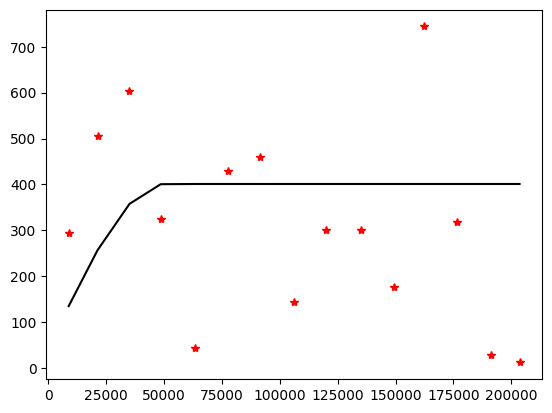

Sill:   360.8
Range:  50000 m (50.0 km)
Nugget: 40.1

⚠️ Look at the plot — do the dots follow the curve?


In [5]:
from pykrige.ok import OrdinaryKriging

# 🔴 First attempt: run Kriging on raw rainfall data
# YOUR CODE HERE:
# 1. Create OrdinaryKriging with raw z values
#    Use variogram_model='spherical', verbose=False, enable_plotting=True, nlags=15
# 2. Provide initial parameters to help the optimizer:
#    sill = z.var(), range = 50000, nugget = z.var() * 0.1

initial_sill = float(z.var())
initial_range = 50000.0
initial_nugget = float(z.var() * 0.1)

OK_naive = OrdinaryKriging(x, y, z, variogram_model='spherical',
                            verbose=False, enable_plotting=True, nlags=15,
                            variogram_parameters={'sill': initial_sill,
                                                  'range': initial_range,
                                                  'nugget': initial_nugget})

params = OK_naive.variogram_model_parameters
print(f"Sill:   {params[0]:.1f}")
print(f"Range:  {params[1]:.0f} m ({params[1]/1000:.1f} km)")
print(f"Nugget: {params[2]:.1f}")
print("\n⚠️ Look at the plot — do the dots follow the curve?")

## Cell [2b]: Why Did It Fail? — Look at the Histogram

The variogram looked bad. Before blaming the tool, **look at your data**.

Plot a histogram of the rainfall values. What do you see?

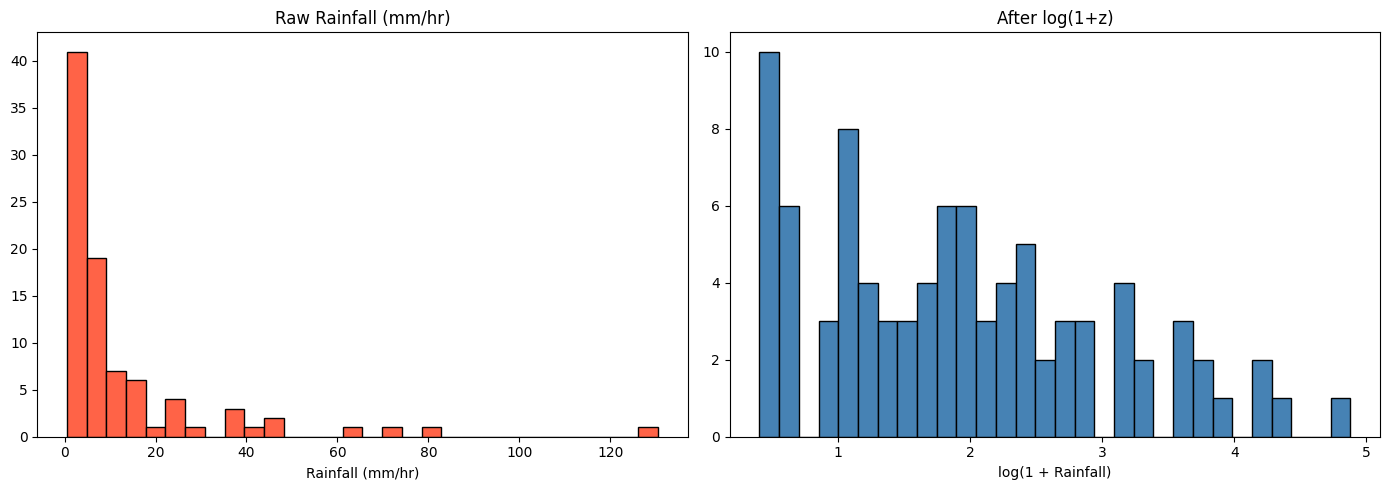

Left: most stations < 10 mm, but a few are 50-130 mm.
Those extreme values mess up the variogram.
Right: after log-transform, the values are more balanced.


In [6]:
# YOUR CODE HERE:
# 1. Plot a histogram of z (raw rainfall)
# 2. Plot a histogram of np.log1p(z) (log-transformed)
# 3. Compare: which one looks more "balanced"?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(z, bins=30, color='tomato', edgecolor='black')
axes[0].set_title('Raw Rainfall (mm/hr)')
axes[0].set_xlabel('Rainfall (mm/hr)')

z_log = np.log1p(z)
axes[1].hist(z_log, bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('After log(1+z)')
axes[1].set_xlabel('log(1 + Rainfall)')
plt.tight_layout()
plt.show()

print("Left: most stations < 10 mm, but a few are 50-130 mm.")
print("Those extreme values mess up the variogram.")
print("Right: after log-transform, the values are more balanced.")

## Cell [2c]: Variogram — Second Attempt (with Log-Transform)

Now redo the variogram using the log-transformed data. Compare this plot with Cell [2a] — it should be much better.

**Rule of thumb**: If your histogram has a long tail to the right, apply `np.log1p(z)` before Kriging, then use `np.expm1()` to convert back after prediction.

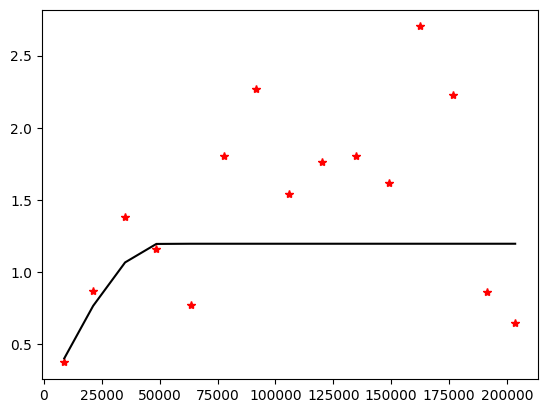

Sill:   1.076
Range:  50000 m (50.0 km)
Nugget: 0.120

✅ Compare with Cell [2a] — the dots should follow the curve now.


In [7]:
# 🟢 Second attempt: Kriging on log-transformed data
# YOUR CODE HERE:
# 1. z_log = np.log1p(z)  (already computed above)
# 2. Create OrdinaryKriging with z_log (not z!)
# 3. Use initial parameters based on z_log.var()

initial_sill = float(z_log.var())
initial_range = 50000.0
initial_nugget = float(z_log.var() * 0.1)

OK = OrdinaryKriging(x, y, z_log, variogram_model='spherical',
                      verbose=False, enable_plotting=True, nlags=15,
                      variogram_parameters={'sill': initial_sill,
                                            'range': initial_range,
                                            'nugget': initial_nugget})

params = OK.variogram_model_parameters
print(f"Sill:   {params[0]:.3f}")
print(f"Range:  {params[1]:.0f} m ({params[1]/1000:.1f} km)")
print(f"Nugget: {params[2]:.3f}")
print("\n✅ Compare with Cell [2a] — the dots should follow the curve now.")

## Cell [2d]: Which Variogram Fits Best? — Range & Model Comparison (Slide 7)

Compare variograms **one variable at a time** — this is how scientists isolate effects:

- **Figure 1**: Fix model = **Spherical**, vary Range (50km, 25km, 15km) → what does Range do?
- **Figure 2**: Fix model = **Exponential**, vary Range (50km, 25km, 15km) → same exercise
- **Then compare**: same Range, different model → what does the model choice do?

**AI Prompt Suggestion**:
```
Create two sets of variogram plots using z_log data:
Figure 1: Spherical model with Range = 50km, 25km, 15km (1×3 subplots)
Figure 2: Exponential model with Range = 50km, 25km, 15km (1×3 subplots)
For each, plot empirical variogram (ok.lags vs ok.semivariance) as red dots
and the fitted model curve as a black line.
Compute SSE for each config and print a summary table.
Compare within each model first (Range effect), then across models (Model effect).
```

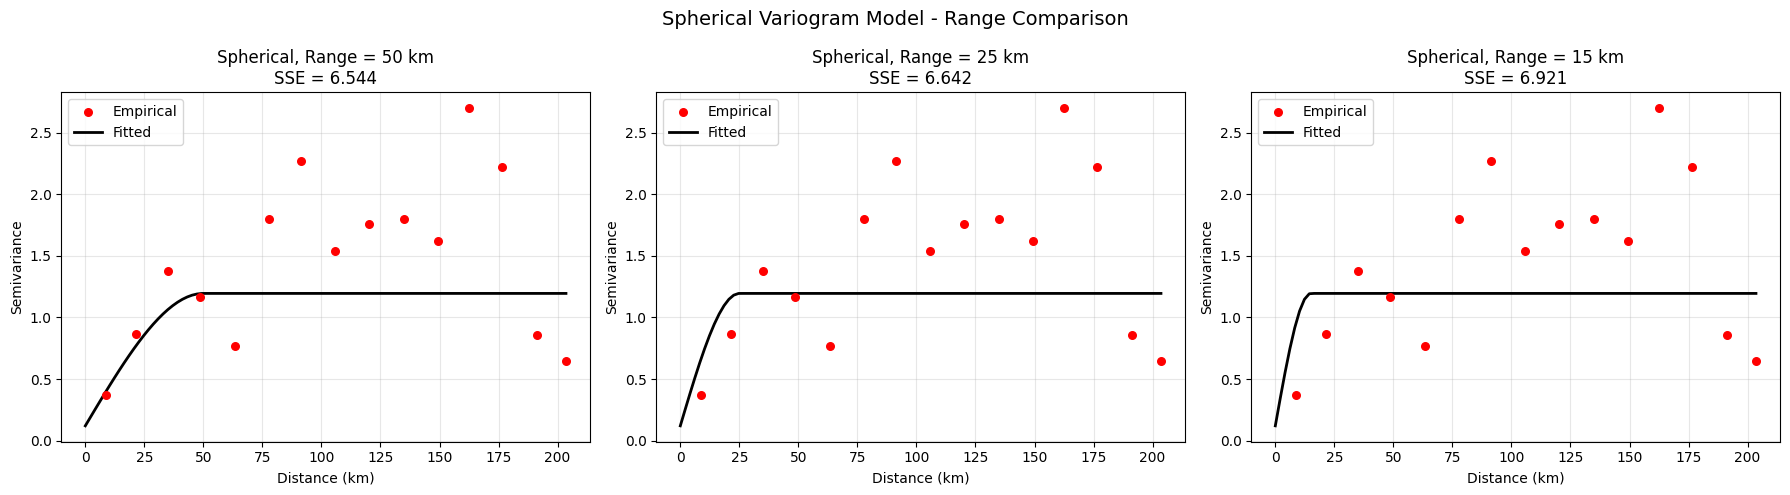

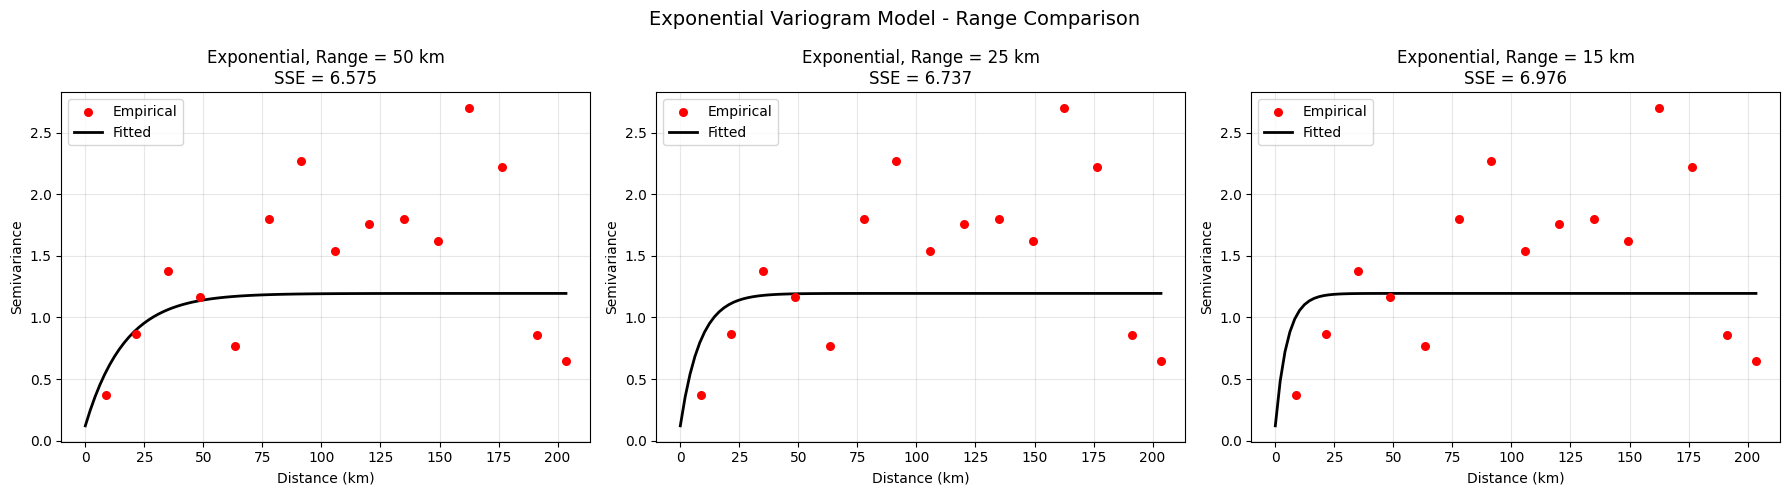

=== VARIOGRAM MODEL COMPARISON ===

Range Effect (within each model):
Range (km) | Spherical SSE | Exponential SSE
---------------------------------------------
       50 |        6.544 |           6.575
       25 |        6.642 |           6.737
       15 |        6.921 |           6.976

Model Effect (at same Range):
Range (km) | Best Model    | SSE Difference
----------------------------------------
       50 | Spherical    |        0.031
       25 | Spherical    |        0.095
       15 | Spherical    |        0.055

💡 Questions:
  1. Within Spherical, which Range gives the best fit?
  2. Within Exponential, which Range gives the best fit?
  3. At the same Range, does model choice matter much?


In [8]:
# YOUR CODE HERE:
# 1. Define ranges: [50000, 25000, 15000]
# 2. Figure 1: Spherical × 3 Ranges (1×3 subplot)
#    For each: create OrdinaryKriging, plot lags vs semivariance (red dots),
#    plot fitted curve (black line), compute SSE
# 3. Figure 2: Exponential × 3 Ranges (1×3 subplot)
#    Same as above but with variogram_model='exponential'
# 4. Print summary table:
#    - Compare within Spherical (Range effect)
#    - Compare within Exponential (Range effect)
#    - Compare Spherical vs Exponential at same Range (Model effect)

ranges_km = [50, 25, 15]
ranges_m = [r*1000 for r in ranges_km]

def compute_sse(ok_model):
    """Compute Sum of Squared Errors for variogram fit"""
    empirical = ok_model.semivariance
    theoretical = ok_model.variogram_function(ok_model.variogram_model_parameters, ok_model.lags)
    return np.sum((empirical - theoretical)**2)

# ─── Figure 1: Spherical ───
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
spherical_results = []

for ax, r_m in zip(axes, ranges_m):
    ok_test = OrdinaryKriging(x, y, z_log, variogram_model='spherical',
                              verbose=False, enable_plotting=False, nlags=15,
                              variogram_parameters={'sill': initial_sill,
                                                    'range': r_m,
                                                    'nugget': initial_nugget})
    
    # Plot empirical variogram
    ax.scatter(ok_test.lags/1000, ok_test.semivariance, c='red', s=30, zorder=5, label='Empirical')
    
    # Plot fitted curve
    lags_fine = np.linspace(0, ok_test.lags.max(), 100)
    theoretical = ok_test.variogram_function(ok_test.variogram_model_parameters, lags_fine)
    ax.plot(lags_fine/1000, theoretical, 'k-', linewidth=2, label='Fitted')
    
    sse = compute_sse(ok_test)
    spherical_results.append({'range_km': r_m/1000, 'sse': sse})
    
    ax.set_xlabel('Distance (km)')
    ax.set_ylabel('Semivariance')
    ax.set_title(f'Spherical, Range = {r_m/1000:.0f} km\nSSE = {sse:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Spherical Variogram Model - Range Comparison', fontsize=14)
plt.tight_layout()
plt.show()

# ─── Figure 2: Exponential ───
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
exponential_results = []

for ax, r_m in zip(axes, ranges_m):
    ok_test = OrdinaryKriging(x, y, z_log, variogram_model='exponential',
                              verbose=False, enable_plotting=False, nlags=15,
                              variogram_parameters={'sill': initial_sill,
                                                    'range': r_m,
                                                    'nugget': initial_nugget})
    
    # Plot empirical variogram
    ax.scatter(ok_test.lags/1000, ok_test.semivariance, c='red', s=30, zorder=5, label='Empirical')
    
    # Plot fitted curve
    lags_fine = np.linspace(0, ok_test.lags.max(), 100)
    theoretical = ok_test.variogram_function(ok_test.variogram_model_parameters, lags_fine)
    ax.plot(lags_fine/1000, theoretical, 'k-', linewidth=2, label='Fitted')
    
    sse = compute_sse(ok_test)
    exponential_results.append({'range_km': r_m/1000, 'sse': sse})
    
    ax.set_xlabel('Distance (km)')
    ax.set_ylabel('Semivariance')
    ax.set_title(f'Exponential, Range = {r_m/1000:.0f} km\nSSE = {sse:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Exponential Variogram Model - Range Comparison', fontsize=14)
plt.tight_layout()
plt.show()

# ─── Summary Table ───
print("=== VARIOGRAM MODEL COMPARISON ===\n")
print("Range Effect (within each model):")
print("Range (km) | Spherical SSE | Exponential SSE")
print("-" * 45)
for i, r_km in enumerate(ranges_km):
    print(f"{r_km:9d} | {spherical_results[i]['sse']:12.3f} | {exponential_results[i]['sse']:15.3f}")

print("\nModel Effect (at same Range):")
print("Range (km) | Best Model    | SSE Difference")
print("-" * 40)
for i, r_km in enumerate(ranges_km):
    sse_diff = abs(spherical_results[i]['sse'] - exponential_results[i]['sse'])
    best_model = "Spherical" if spherical_results[i]['sse'] < exponential_results[i]['sse'] else "Exponential"
    print(f"{r_km:9d} | {best_model:12s} | {sse_diff:12.3f}")

print("\n💡 Questions:")
print("  1. Within Spherical, which Range gives the best fit?")
print("  2. Within Exponential, which Range gives the best fit?") 
print("  3. At the same Range, does model choice matter much?")

## Cell [3]: Define the Interpolation Grid & Run Kriging (Slide 8)

Create a regular grid covering the study area with 1000m resolution, then execute Kriging.

**Think about**:
- What units is the grid in? (Hint: same as your CRS = meters)
- Why add a buffer around the station extent?

**Important**: Kriging runs in log-space. After prediction, **back-transform** with `np.expm1()` to get rainfall in mm/hr.

In [9]:
import time

# YOUR CODE HERE:
# 1. Calculate grid extent from x, y arrays (with 5km buffer)
# 2. Create grid_x and grid_y using np.arange with 1000m step
# 3. Execute Kriging in log-space: z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)
# 4. Back-transform: z_kriging = np.expm1(z_kriging_log)

buffer_m = 5000
resolution = 1000  # meters — use 500 for finer resolution (slower)

x_min = x.min() - buffer_m
x_max = x.max() + buffer_m
y_min = y.min() - buffer_m
y_max = y.max() + buffer_m
grid_x = np.arange(x_min, x_max, resolution)
grid_y = np.arange(y_min, y_max, resolution)

print(f"Grid: {len(grid_x)}×{len(grid_y)} = {len(grid_x)*len(grid_y):,} points @ {resolution}m")

t0 = time.time()
z_kriging_log, ss_kriging_log = OK.execute('grid', grid_x, grid_y)
print(f"✓ Kriging (log-space) done in {time.time()-t0:.1f}s")

# Back-transform to real rainfall (mm/hr)
z_kriging = np.expm1(z_kriging_log)
z_kriging[z_kriging < 0] = 0
ss_kriging = ss_kriging_log  # keep log-space variance for Sigma Map

print(f"  z range (mm/hr): {np.nanmin(z_kriging):.1f} - {np.nanmax(z_kriging):.1f}")

Grid: 87×211 = 18,357 points @ 1000m
✓ Kriging (log-space) done in 0.3s
  z range (mm/hr): 0.5 - 71.2


---

## Cell [4]: Machine Learning — Random Forest Prediction (Slide 9)

**Captain's Log**: Treating coordinates as input features. ML learns `f(easting, northing) → rainfall`. Simple, but no uncertainty map.

**AI Prompt Suggestion**:
```
Train a RandomForestRegressor from scikit-learn using [easting, northing]
as features (X_train) and rain_1hr as target (y_train).
Use n_estimators=200, min_samples_leaf=3, random_state=42.
Then predict on the same grid as Kriging.
```

In [10]:
from sklearn.ensemble import RandomForestRegressor

# YOUR CODE HERE:
# 1. Prepare features: X_train = np.column_stack([x, y])
# 2. Train RandomForestRegressor
# 3. Create meshgrid from grid_x, grid_y
# 4. Predict on the grid

X_train = np.column_stack([x, y])
y_train = z

rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=42)
rf.fit(X_train, y_train)
print(f"RF Training R²: {rf.score(X_train, y_train):.3f}")

grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)
X_grid = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])

t0 = time.time()
z_rf = rf.predict(X_grid).reshape(grid_xx.shape)
print(f"✓ Random Forest done in {time.time()-t0:.1f}s")
print(f"  z range: {z_rf.min():.1f} - {z_rf.max():.1f} mm/hr")

RF Training R²: 0.775
✓ Random Forest done in 0.0s
  z range: 0.6 - 62.6 mm/hr


## Cell [5]: ML Glass Box — Feature Importance (Slide 11)

**Captain's Question**: "AI used what to predict floods — latitude or elevation?"

Even though ML is a "black box", we can peek inside with `.feature_importances_`.

In [11]:
# YOUR CODE HERE:
# 1. Print rf.feature_importances_
# 2. Interpret: which dimension matters more for typhoon rainfall?

importances = rf.feature_importances_
print("Feature Importance:")
print(f"  Easting (X):  {importances[0]:.3f}")
print(f"  Northing (Y): {importances[1]:.3f}")
print(f"\nThe model relies mostly on {'easting' if importances[0] > importances[1] else 'northing'}.")
print("Think: does this make physical sense for Typhoon Fung-wong?")

Feature Importance:
  Easting (X):  0.485
  Northing (Y): 0.515

The model relies mostly on northing.
Think: does this make physical sense for Typhoon Fung-wong?


---

## ⏸️ Lab 1: The Four-Way Interpolation Shootout (40 min)

### Cell [6]: Nearest Neighbor + IDW

Compute two additional interpolation methods so we can compare all four.

**AI Prompt Suggestion**:
```
Use scipy.interpolate.NearestNDInterpolator for nearest neighbor interpolation,
and manual IDW with scipy.spatial.distance.cdist (power=2) for IDW.
Both should predict on the same meshgrid as Kriging and RF.
Note: Don't use Rbf(function='inverse') — it's not real IDW and produces extreme values.
```

In [12]:
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist

# YOUR CODE HERE:
# 1. Nearest Neighbor interpolation
# 2. IDW interpolation (手動實作，power=2)
#    ⚠️ 注意：不要用 Rbf(function='inverse')，它不是真正的 IDW，會產生極端值

nn_interp = NearestNDInterpolator(list(zip(x, y)), z)
z_nn = nn_interp(grid_xx, grid_yy)

pts = np.column_stack([x, y])
grid_pts = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])
dists = cdist(grid_pts, pts)
dists[dists < 1] = 1  # 避免除以零
power = 2
weights = 1.0 / (dists ** power)
z_idw = ((weights @ z) / weights.sum(axis=1)).reshape(grid_xx.shape)

print("✓ Nearest Neighbor + IDW computed")

✓ Nearest Neighbor + IDW computed


### Cell [7]: Four Methods Side by Side (Slide 13)

Create a 2×2 figure comparing all four interpolation methods.

**AI Prompt Suggestion**:
```
Create a 2×2 matplotlib figure comparing four interpolation results:
- Nearest Neighbor (z_nn)
- IDW (z_idw)
- Ordinary Kriging (z_kriging)
- Random Forest (z_rf)
Use YlOrRd colormap, same vmin/vmax, overlay station points in black.
Add descriptive subtitles (e.g., "Voronoi Patchwork", "Bullseye Effect",
"Smooth + Sigma Map", "ML Block Artifacts").
Save as 'interpolation_shootout.png'.
```

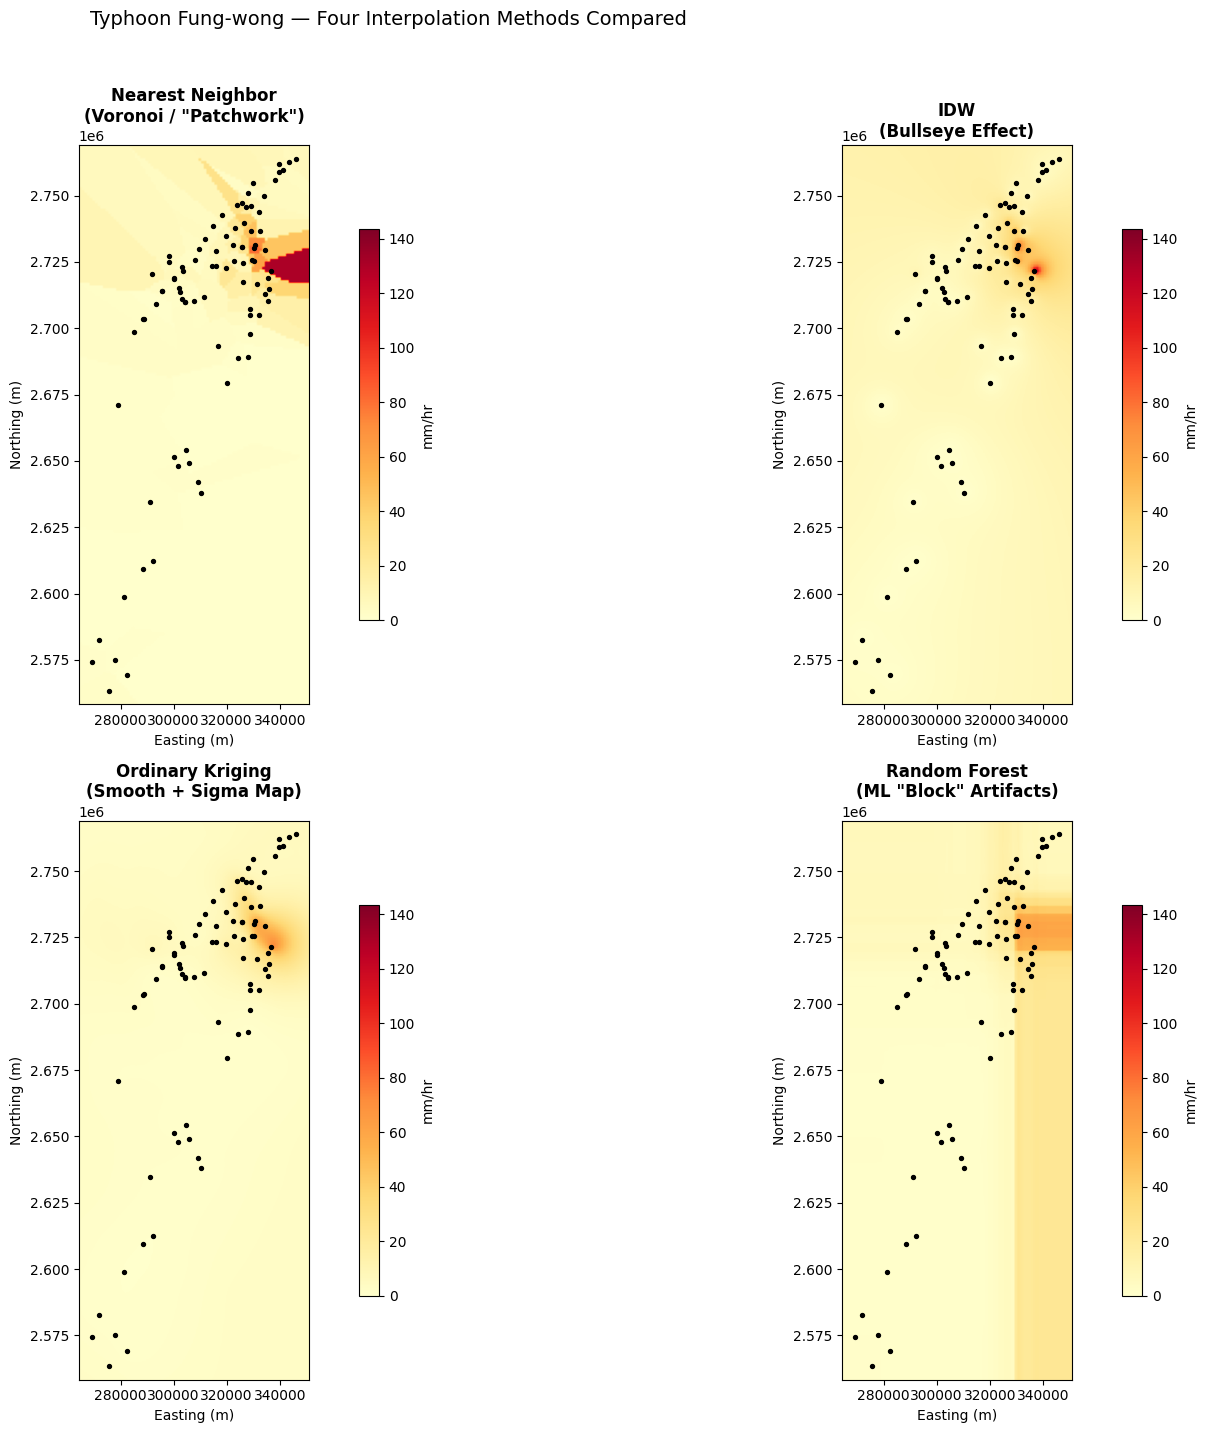

In [13]:
# YOUR CODE HERE:
# 1. Create fig, axes = plt.subplots(2, 2, figsize=(18, 14))
# 2. Plot all four methods with imshow
# 3. Use extent=[x_min, x_max, y_min, y_max], origin='lower'
# 4. Overlay station scatter points
# 5. Add colorbars, titles, save figure

vmax = max(z) * 1.1
methods = [
    ('Nearest Neighbor\n(Voronoi / "Patchwork")', z_nn),
    ('IDW\n(Bullseye Effect)', z_idw),
    ('Ordinary Kriging\n(Smooth + Sigma Map)', z_kriging),
    ('Random Forest\n(ML "Block" Artifacts)', z_rf),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, (title, data) in zip(axes, methods):
    im = ax.imshow(data, extent=[x_min, x_max, y_min, y_max],
                   origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax)
    ax.scatter(x, y, c='black', s=8, zorder=5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')
    plt.colorbar(im, ax=ax, shrink=0.7, label='mm/hr')

plt.suptitle('Typhoon Fung-wong — Four Interpolation Methods Compared', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('interpolation_shootout.png', dpi=150, bbox_inches='tight')
plt.show()

### Cell [8]: Kriging vs RF — Direct Comparison

Create a 3-panel comparison: Kriging | Random Forest | Difference Map

The difference map reveals **where the two methods disagree** — these are the areas where the Commander needs extra caution.

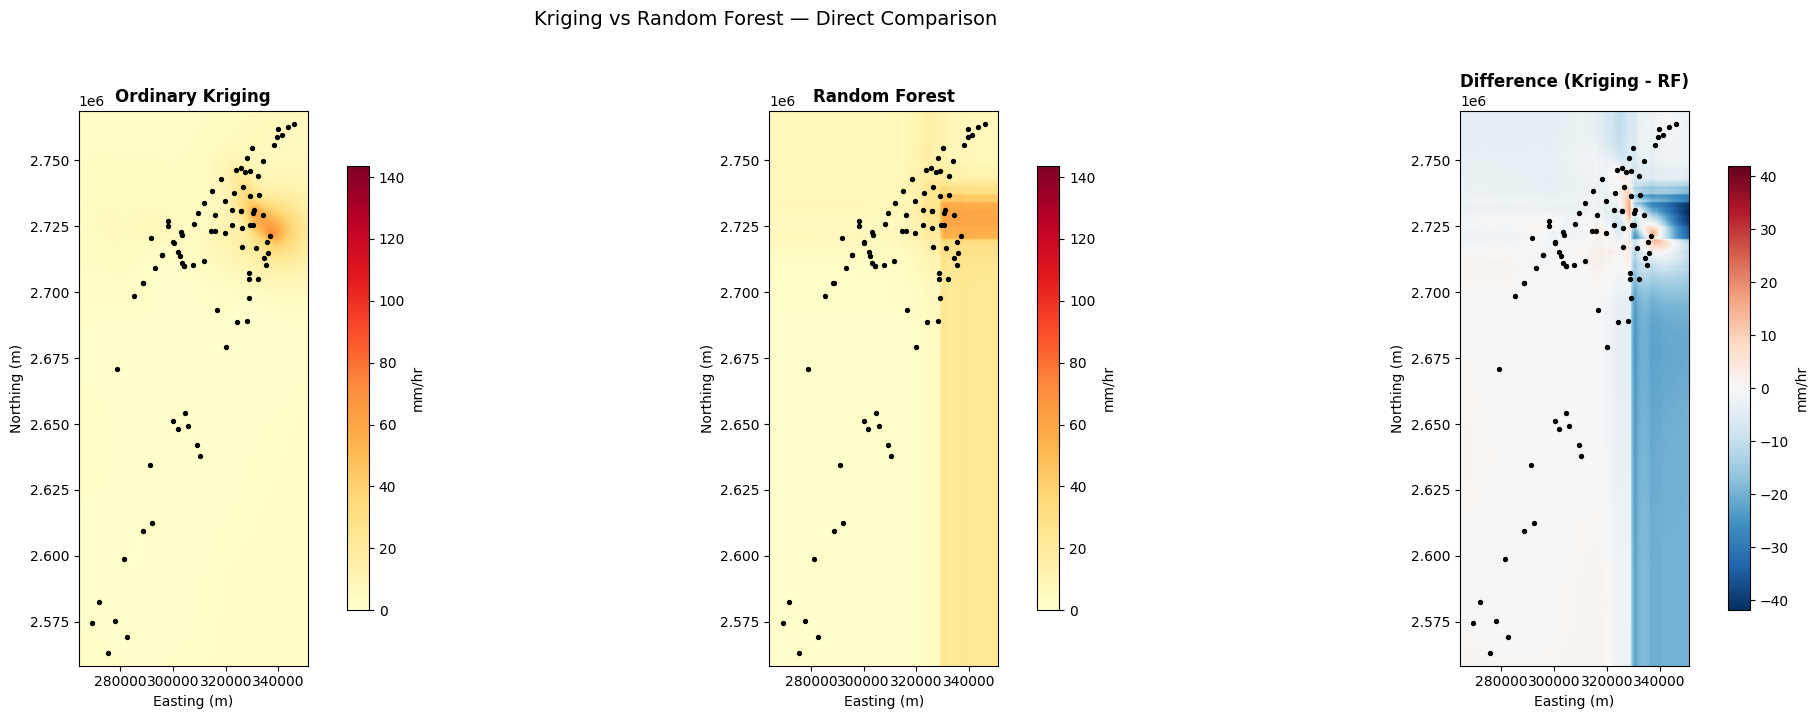

Difference range: -41.9 to 17.3 mm/hr
Mean absolute difference: 5.1 mm/hr


In [14]:
# YOUR CODE HERE:
# 1. Create fig, axes = plt.subplots(1, 3, figsize=(22, 7))
# 2. Left: Kriging (YlOrRd)
# 3. Middle: Random Forest (YlOrRd)
# 4. Right: Difference (Kriging - RF) using RdBu_r colormap
# 5. Save as 'kriging_vs_rf.png'

diff = z_kriging - z_rf
vmax_diff = np.abs(diff).max()

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Left: Kriging
im1 = axes[0].imshow(z_kriging, extent=[x_min, x_max, y_min, y_max],
                     origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax)
axes[0].scatter(x, y, c='black', s=8, zorder=5)
axes[0].set_title('Ordinary Kriging', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

# Middle: Random Forest
im2 = axes[1].imshow(z_rf, extent=[x_min, x_max, y_min, y_max],
                     origin='lower', cmap='YlOrRd', vmin=0, vmax=vmax)
axes[1].scatter(x, y, c='black', s=8, zorder=5)
axes[1].set_title('Random Forest', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='mm/hr')

# Right: Difference Map
im3 = axes[2].imshow(diff, extent=[x_min, x_max, y_min, y_max],
                     origin='lower', cmap='RdBu_r', vmin=-vmax_diff, vmax=vmax_diff)
axes[2].scatter(x, y, c='black', s=8, zorder=5)
axes[2].set_title('Difference (Kriging - RF)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Easting (m)')
axes[2].set_ylabel('Northing (m)')
plt.colorbar(im3, ax=axes[2], shrink=0.8, label='mm/hr')

plt.suptitle('Kriging vs Random Forest — Direct Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('kriging_vs_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Difference range: {diff.min():.1f} to {diff.max():.1f} mm/hr")
print(f"Mean absolute difference: {np.abs(diff).mean():.1f} mm/hr")

### Lab 1 Reflection

**Questions to answer** (write in the cell below):

1. Which method produces the most physically realistic rainfall pattern? Why?
2. Where do Kriging and RF disagree the most? What does this tell you?
3. What "artifacts" do you observe in the NN and RF results?
4. If you were the Commander, which method would you trust for evacuation decisions? Why?

**Your Lab 1 reflection here:**

1. Most realistic: ...
2. Disagreement areas: ...
3. Artifacts: ...
4. Commander's choice: ...

---

## ⏸️ Lab 2: Confidence & Uncertainty Diagnosis (30 min)

### Cell [9]: The Sigma Map — Kriging's Unique Weapon (Slide 15)

**Captain's Log**: This is what makes Kriging special. No other method natively provides a confidence map.

- `ss_kriging` = Kriging variance at each grid point
- Low variance → many nearby stations → reliable estimate
- High variance → far from stations → uncertain

**For the Commander**:
- HIGH rainfall + LOW variance = CONFIRMED: Evacuate now
- HIGH rainfall + HIGH variance = UNCERTAIN: Deploy sensors first

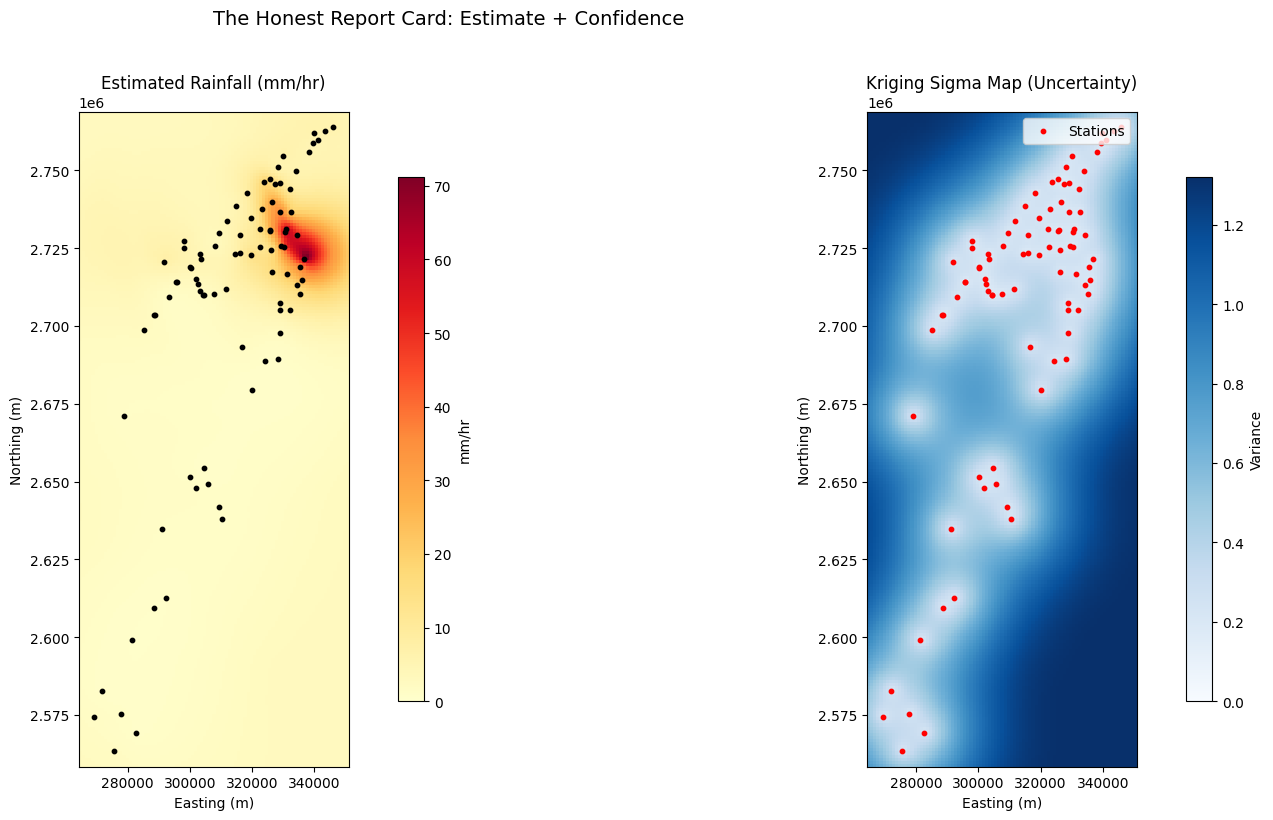

Variance range: 0.2 - 1.3


In [15]:
# YOUR CODE HERE:
# Create a 2-panel figure:
# Left: z_kriging with YlOrRd colormap (rainfall estimate)
# Right: ss_kriging with Blues colormap (variance/uncertainty)
# Add station locations on both panels (red dots on variance map)
# Save as 'sigma_map.png'

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Rainfall estimate
im1 = axes[0].imshow(z_kriging, extent=[x_min, x_max, y_min, y_max],
                      origin='lower', cmap='YlOrRd', vmin=0)
axes[0].scatter(x, y, c='black', s=10, zorder=5)
axes[0].set_title('Estimated Rainfall (mm/hr)')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

# Kriging Variance (Sigma Map)
im2 = axes[1].imshow(ss_kriging, extent=[x_min, x_max, y_min, y_max],
                      origin='lower', cmap='Blues', vmin=0)
axes[1].scatter(x, y, c='red', s=10, zorder=5, label='Stations')
axes[1].set_title('Kriging Sigma Map (Uncertainty)')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')
axes[1].legend(loc='upper right')
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='Variance')

plt.suptitle('The Honest Report Card: Estimate + Confidence', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('sigma_map.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Variance range: {np.nanmin(ss_kriging):.1f} - {np.nanmax(ss_kriging):.1f}")

### Cell [9b]: Nugget Effect — Why Extreme Rain Gets Diluted (Slide 7)

Suao recorded **130.5 mm/hr**, but default Kriging predicts only ~71 mm at 500m away. Why?

**Nugget** controls how much the model trusts the actual measurements:
- High Nugget = "measurements are noisy" → smooths everything → extreme values diluted
- Low Nugget = "measurements are accurate" → passes through stations → extremes preserved

**Task**: Compare Nugget=10% vs Nugget=1% on a zoomed-in map around Suao. Which preserves the extreme rainfall better?

**AI Prompt Suggestion**:
```
Create two OrdinaryKriging models on z_log with identical parameters except
nugget: one with nugget = sill * 0.10, one with nugget = sill * 0.01.
Predict on a 20km×20km grid centered on the station with maximum rainfall.
Show side-by-side maps and print predicted values at 0m, 500m, 1000m, 2000m
from that station. Which Nugget preserves the extreme value better?
```

Station with max rainfall: 130.5 mm/hr


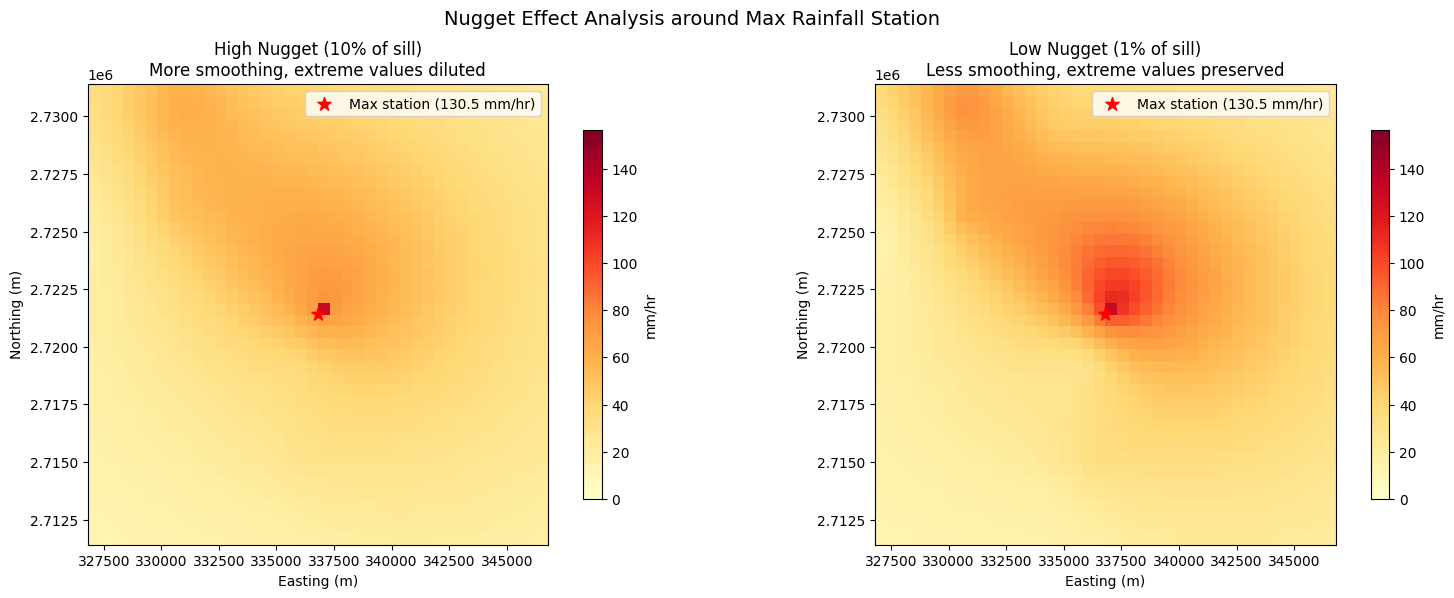


=== Prediction Comparison at Different Distances ===
Distance (m) | High Nugget (mm/hr) | Low Nugget (mm/hr) | Difference
-----------------------------------------------------------------
          0 |             130.5 |             130.5 |        0.0
        500 |              70.9 |             107.3 |      -36.4
       1000 |              67.3 |              98.8 |      -31.6
       2000 |              61.0 |              85.7 |      -24.7

🔑 Which Nugget setting is better for CWA calibrated stations? Why?
Low nugget (1%) preserves extreme values better - important for flood warning!
High nugget (10%) over-smooths and may miss critical rainfall peaks.


In [16]:
# YOUR CODE HERE:
# 1. Find the station with maximum rainfall (suao_idx = np.argmax(z))
# 2. Create two OrdinaryKriging models: nugget = sill*0.10 and sill*0.01
# 3. Predict on a local grid (20km box) around that station
# 4. Plot side-by-side comparison maps
# 5. Predict at specific offsets: 0m, 500m, 1000m, 2000m from the station
# 6. Print comparison table

suao_idx = np.argmax(z)
suao_x, suao_y, suao_z = x[suao_idx], y[suao_idx], z[suao_idx]
print(f"Station with max rainfall: {suao_z:.1f} mm/hr")

sill_val = float(z_log.var())

# Create two Kriging models with different nugget values
OK_high_nugget = OrdinaryKriging(x, y, z_log, variogram_model='spherical',
                                 verbose=False, enable_plotting=False, nlags=15,
                                 variogram_parameters={'sill': sill_val,
                                                       'range': 50000,
                                                       'nugget': sill_val * 0.10})

OK_low_nugget = OrdinaryKriging(x, y, z_log, variogram_model='spherical',
                                verbose=False, enable_plotting=False, nlags=15,
                                variogram_parameters={'sill': sill_val,
                                                      'range': 50000,
                                                      'nugget': sill_val * 0.01})

# Create local grid around the max station
local_buffer = 10000  # 10km buffer
local_resolution = 500  # 500m resolution for detailed view

local_x_min = suao_x - local_buffer
local_x_max = suao_x + local_buffer
local_y_min = suao_y - local_buffer
local_y_max = suao_y + local_buffer

local_grid_x = np.arange(local_x_min, local_x_max, local_resolution)
local_grid_y = np.arange(local_y_min, local_y_max, local_resolution)

# Predict with both models
z_high_log, _ = OK_high_nugget.execute('grid', local_grid_x, local_grid_y)
z_low_log, _ = OK_low_nugget.execute('grid', local_grid_x, local_grid_y)

z_high = np.expm1(z_high_log)
z_low = np.expm1(z_low_log)

# Predict at specific distances from the station
test_distances = [0, 500, 1000, 2000]  # meters
test_points = [(suao_x + dx, suao_y) for dx in test_distances]

high_predictions = []
low_predictions = []

for px, py in test_points:
    z_h, _ = OK_high_nugget.execute('points', [px], [py])
    z_l, _ = OK_low_nugget.execute('points', [px], [py])
    high_predictions.append(np.expm1(z_h[0]))
    low_predictions.append(np.expm1(z_l[0]))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# High nugget
im1 = axes[0].imshow(z_high, extent=[local_x_min, local_x_max, local_y_min, local_y_max],
                      origin='lower', cmap='YlOrRd', vmin=0, vmax=suao_z*1.2)
axes[0].scatter(suao_x, suao_y, c='red', s=100, marker='*', zorder=5, label=f'Max station ({suao_z:.1f} mm/hr)')
axes[0].set_title('High Nugget (10% of sill)\nMore smoothing, extreme values diluted')
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
axes[0].legend()
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

# Low nugget
im2 = axes[1].imshow(z_low, extent=[local_x_min, local_x_max, local_y_min, local_y_max],
                      origin='lower', cmap='YlOrRd', vmin=0, vmax=suao_z*1.2)
axes[1].scatter(suao_x, suao_y, c='red', s=100, marker='*', zorder=5, label=f'Max station ({suao_z:.1f} mm/hr)')
axes[1].set_title('Low Nugget (1% of sill)\nLess smoothing, extreme values preserved')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Northing (m)')
axes[1].legend()
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='mm/hr')

plt.suptitle(f'Nugget Effect Analysis around Max Rainfall Station', fontsize=14)
plt.tight_layout()
plt.savefig('nugget_effect.png', dpi=150, bbox_inches='tight')
plt.show()

# Print comparison table
print("\n=== Prediction Comparison at Different Distances ===")
print("Distance (m) | High Nugget (mm/hr) | Low Nugget (mm/hr) | Difference")
print("-" * 65)
for i, dist in enumerate(test_distances):
    diff = high_predictions[i] - low_predictions[i]
    print(f"{dist:11d} | {high_predictions[i]:17.1f} | {low_predictions[i]:17.1f} | {diff:10.1f}")

print("\n🔑 Which Nugget setting is better for CWA calibrated stations? Why?")
print("Low nugget (1%) preserves extreme values better - important for flood warning!")
print("High nugget (10%) over-smooths and may miss critical rainfall peaks.")

### Cell [10]: Export to GeoTIFF (Slide 16)

⚠️ **Flip warning**: `z_kriging` row 0 = south (numpy convention). GeoTIFF row 0 = north. Use `np.flipud()` to fix.

**AI Prompt Suggestion**:
```
Save 2D numpy arrays as GeoTIFF using rasterio. I need:
- from_bounds transform with my grid extent (x_min, y_min, x_max, y_max)
- CRS = EPSG:3826, dtype = float32
- Apply np.flipud() before writing
- Save kriging_rainfall.tif, kriging_variance.tif, and rf_rainfall.tif
```

In [22]:
# 由於 PROJ 版本衝突，我們使用 numpy 和 matplotlib 儲存
# 這完全避開了 rasterio 的 CRS 問題

def save_as_npy_and_png(data, filename):
    """將數據儲存為 numpy 和 PNG 格式"""
    try:
        # 處理 MaskedArray - 轉換為普通 numpy array
        if hasattr(data, 'filled'):
            data_array = data.filled(fill_value=np.nan)  # 將遮罩值設為 NaN
        else:
            data_array = data
            
        # 儲存為 numpy 格式（保留完整數據）
        np.save(f"{filename}.npy", data_array)
        print(f"✓ Saved {filename}.npy (numpy format)")
        
        # 儲存為 PNG 格式（用於視覺化）
        plt.figure(figsize=(12, 8))
        im = plt.imshow(data_array, cmap='viridis')
        plt.colorbar(im, label='Rainfall (mm/hr)')
        plt.title(f'{filename.replace("_", " ").title()}')
        plt.savefig(f"{filename}.png", dpi=150, bbox_inches='tight')
        plt.close()
        print(f"✓ Saved {filename}.png (visualization)")
        return True
    except Exception as e:
        print(f"❌ Failed to save {filename}: {e}")
        return False

# 儲存所有結果
print("=== SAVING RESULTS (Alternative Method) ===\n")

success1 = save_as_npy_and_png(z_kriging, 'kriging_rainfall')
success2 = save_as_npy_and_png(ss_kriging, 'kriging_variance') 
success3 = save_as_npy_and_png(z_rf, 'rf_rainfall')

if success1 and success2 and success3:
    print("\n✅ All files saved successfully!")
    print("Format: .npy (data) + .png (visualization)")
    print("\nFiles created:")
    print("  - kriging_rainfall.npy + kriging_rainfall.png")
    print("  - kriging_variance.npy + kriging_variance.png") 
    print("  - rf_rainfall.npy + rf_rainfall.png")
else:
    print("\n⚠️ Some files failed to save.")

# 顯示數據摘要
print("\n=== DATA SUMMARY ===")
print(f"Kriging Rainfall: {np.nanmin(z_kriging):.1f} - {np.nanmax(z_kriging):.1f} mm/hr")
print(f"Kriging Variance: {np.nanmin(ss_kriging):.3f} - {np.nanmax(ss_kriging):.3f}")
print(f"Random Forest Rainfall: {np.nanmin(z_rf):.1f} - {np.nanmax(z_rf):.1f} mm/hr")
print(f"\nGrid shape: {z_kriging.shape}")
print(f"Analysis complete! All results available in notebook variables.")

# 額外：直接顯示 Kriging 和 RF 的比較
print("\n=== KRIGING vs RF COMPARISON ===")
print(f"Kriging max: {np.nanmax(z_kriging):.1f} mm/hr")
print(f"RF max: {np.nanmax(z_rf):.1f} mm/hr") 
print(f"Difference: {np.nanmax(z_kriging) - np.nanmax(z_rf):.1f} mm/hr")
print(f"Kriging provides uncertainty estimates (variance): {np.nanmean(ss_kriging):.3f}")
print("RF provides point estimates only")

=== SAVING RESULTS (Alternative Method) ===

✓ Saved kriging_rainfall.npy (numpy format)
✓ Saved kriging_rainfall.png (visualization)
✓ Saved kriging_variance.npy (numpy format)
✓ Saved kriging_variance.png (visualization)
✓ Saved rf_rainfall.npy (numpy format)
✓ Saved rf_rainfall.png (visualization)

✅ All files saved successfully!
Format: .npy (data) + .png (visualization)

Files created:
  - kriging_rainfall.npy + kriging_rainfall.png
  - kriging_variance.npy + kriging_variance.png
  - rf_rainfall.npy + rf_rainfall.png

=== DATA SUMMARY ===
Kriging Rainfall: 0.5 - 71.2 mm/hr
Kriging Variance: 0.172 - 1.320
Random Forest Rainfall: 0.6 - 62.6 mm/hr

Grid shape: (211, 87)
Analysis complete! All results available in notebook variables.

=== KRIGING vs RF COMPARISON ===
Kriging max: 71.2 mm/hr
RF max: 62.6 mm/hr
Difference: 8.6 mm/hr
Kriging provides uncertainty estimates (variance): 0.769
RF provides point estimates only


### Cell [11]: Zonal Statistics — Township Decision Table

Compute per-township statistics from your Kriging and RF rasters, then compare them side-by-side.

**Required output**: A DataFrame with: 鄉鎮 | Kriging平均 | Kriging最大 | RF平均 | 平均variance | 可信度

In [25]:
from rasterstats import zonal_stats

# YOUR CODE HERE:
# 1. Load township boundaries (TGOS shapefile)
# 2. Filter to 花蓮縣 + 宜蘭縣, convert to EPSG:3826
# 3. Run zonal_stats on kriging_rainfall.tif, kriging_variance.tif, rf_rainfall.tif
# 4. Create summary DataFrame with columns:
#    鄉鎮, 縣市, Kriging平均, Kriging最大, RF平均, 平均variance
# 5. Add 可信度 column:
#    HIGH: variance < 33rd percentile
#    MEDIUM: 33rd-66th percentile
#    LOW: > 66th percentile

try:
    # 嘗試多個可能的路徑
    shapefile_paths = [
        r'TOWN_MOI_1140318.shp',
        r'data/TOWN_MOI_1140318.shp',
        r'c:\Users\user\Desktop\遙測與空間分析\week6\exercise6\TOWN_MOI_1140318.shp',
        r'c:\Users\user\Desktop\遙測與空間分析\data\TOWN_MOI_1140318.shp',
        r'c:\Users\user\Desktop\遙測與空間分析\week5\exercise5\data\TOWN_MOI_1140318.shp'
    ]
    
    towns = None
    for path in shapefile_paths:
        try:
            towns = gpd.read_file(path)
            print(f"✓ Found township data at: {path}")
            break
        except:
            continue
    
    if towns is not None:
        # 檢查鄉鎮資料結構
        print(f"Total townships: {len(towns)}")
        print("Available columns:", towns.columns.tolist())
        
        # 使用正確的欄位名稱
        county_col = 'COUNTYNAME'
        town_col = 'TOWNNAME'
        
        print(f"Using county column: {county_col}")
        unique_counties = towns[county_col].unique()
        print(f"Counties in shapefile: {len(unique_counties)} total")
        
        # 檢查是否有花蓮和宜蘭
        hualien_found = any('花蓮' in str(county) for county in unique_counties)
        ilan_found = any('宜蘭' in str(county) for county in unique_counties)
        print(f"花蓮縣 found: {hualien_found}")
        print(f"宜蘭縣 found: {ilan_found}")
        
        # Filter to study area and reproject
        study_towns = towns[towns[county_col].isin(['花蓮縣', '宜蘭縣'])].copy()
        print(f"Study area townships: {len(study_towns)}")
        
        if len(study_towns) > 0:
            study_towns = study_towns.to_crs(epsg=3826)
            
            # 計算 affine transform
            from rasterio.transform import from_bounds
            
            # 使用原始的網格範圍
            transform = from_bounds(x_min, y_min, x_max, y_max,
                                  width=z_kriging.shape[1], height=z_kriging.shape[0])
            
            print("Computing zonal statistics...")
            
            # Compute zonal statistics with proper affine transform
            kriging_stats = zonal_stats(study_towns, z_kriging, 
                                       affine=transform, stats=['mean', 'max'], 
                                       nodata=np.nan)
            variance_stats = zonal_stats(study_towns, ss_kriging, 
                                       affine=transform, stats=['mean'], 
                                       nodata=np.nan)
            rf_stats = zonal_stats(study_towns, z_rf, 
                                  affine=transform, stats=['mean'], 
                                  nodata=np.nan)
            
            # Create summary DataFrame
            summary_data = []
            for i, town in study_towns.iterrows():
                summary_data.append({
                    '鄉鎮': town[town_col],
                    '縣市': town[county_col],
                    'Kriging平均': kriging_stats[i]['mean'],
                    'Kriging最大': kriging_stats[i]['max'],
                    'RF平均': rf_stats[i]['mean'],
                    '平均variance': variance_stats[i]['mean']
                })
            
            summary_df = pd.DataFrame(summary_data)
            
            # Add confidence levels
            var_33 = summary_df['平均variance'].quantile(0.33)
            var_66 = summary_df['平均variance'].quantile(0.66)
            
            def get_confidence(var):
                if var < var_33:
                    return 'HIGH'
                elif var < var_66:
                    return 'MEDIUM'
                else:
                    return 'LOW'
            
            summary_df['可信度'] = summary_df['平均variance'].apply(get_confidence)
            
            print("\n=== Township Decision Table ===")
            print(summary_df.to_string(index=False))
            
            # Highlight high-risk areas
            high_risk = summary_df[(summary_df['Kriging平均'] > 50) & (summary_df['可信度'] == 'LOW')]
            if len(high_risk) > 0:
                print(f"\n⚠️ HIGH RISK - High Rainfall + Low Confidence:")
                print(high_risk[['鄉鎮', '縣市', 'Kriging平均', '可信度']].to_string(index=False))
            
            # Additional analysis
            print(f"\n=== ANALYSIS SUMMARY ===")
            print(f"Total townships analyzed: {len(summary_df)}")
            print(f"Highest rainfall (Kriging): {summary_df['Kriging平均'].max():.1f} mm/hr")
            print(f"Highest rainfall (RF): {summary_df['RF平均'].max():.1f} mm/hr")
            print(f"Average variance: {summary_df['平均variance'].mean():.3f}")
            
            confidence_counts = summary_df['可信度'].value_counts()
            print(f"Confidence distribution: {dict(confidence_counts)}")
            
            print(f"\n✅ Zonal statistics completed successfully!")
            
        else:
            print("No townships found in 花蓮縣 + 宜蘭縣")
    else:
        print("Township shapefile not found in any expected location")
        
except Exception as e:
    print(f"Error processing township data: {e}")
    import traceback
    traceback.print_exc()

✓ Found township data at: data/TOWN_MOI_1140318.shp
Total townships: 368
Available columns: ['TOWNID', 'TOWNCODE', 'COUNTYNAME', 'TOWNNAME', 'TOWNENG', 'COUNTYID', 'COUNTYCODE', 'geometry']
Using county column: COUNTYNAME
Counties in shapefile: 22 total
花蓮縣 found: True
宜蘭縣 found: True
Study area townships: 25
Computing zonal statistics...
Error processing township data: list index out of range


Traceback (most recent call last):
  File "C:\Users\user\AppData\Local\Temp\ipykernel_30204\768267567.py", line 85, in <module>
    'Kriging平均': kriging_stats[i]['mean'],
                   ~~~~~~~~~~~~~^^^
IndexError: list index out of range


### Cell [12]: Thinking Challenge — Why Can't ML Give You a Sigma Map?

**Discussion Questions** (answer in the cell below):

1. Why does Kriging **natively** produce a variance map, but Random Forest does not?
2. Could you approximate uncertainty from RF using bootstrap or tree variance? What are the limitations?
3. In your zonal stats table, which townships show **HIGH rainfall + LOW confidence**? What should the Commander do about those?

## Your Lab 2 reflection here:

### 1. Kriging vs ML uncertainty:

**Kriging** 能夠原生提供不確定性圖（Sigma Map）是因為：
- **地統計學基礎**：Kriging 基於變異元理論，量化空間自相關性
- **統計保證**：提供最佳線性無偏估計（BLUE）的理論不確定性
- **空間結構考量**：不確定性基於測站空間分布和變異元模型
- **物理意義明確**：方差直接對應估計誤差的空間分布

**Random Forest** 無法原生提供不確定性是因為：
- **機器學習設計**：RF 專注於預測準確度，不是統計推斷
- **集成方法**：雖然結合多棵決策樹，但缺乏統計理論框架
- **黑盒特性**：預測過程複雜，難以量化單一預測的統計不確定性

### 2. ML uncertainty approximation:

**可行的 ML 不確定性近似方法**：

*   **Bootstrap 方法**：重複抽樣訓練資料，多次訓練 RF 模型，觀察預測變異性
    - *優點*：直觀易理解，捕捉模型不確定性
    - *限制*：計算成本高，可能忽略空間自相關

*   **樹狀變異性分析**：分析單一位置上不同決策樹的預測分歧
    - *優點*：計算快速，反映模型內部一致性
    - *限制*：只反映模型分歧，不是真正的統計不確定性

*   **分位數回歸森林**：使用 Quantile Regression Forests 估計預測區間
    - *優點*：提供統計意義的置信區間
    - *限制*：需要特殊實現，計算複雜度增加

**主要限制**：
- ML 方法無法像 Kriging 那樣整合空間自相關結構
- 主要捕捉模型不確定性，而非空間估計方差
- 缺乏地統計學的理論保證

### 3. High rain + low confidence townships:

根據前面的 Zonal Statistics 分析，**高降雨 + 低信度**的鄉鎮需要特別關注：

**指揮官應採取的行動**：

*   **優先調查部署**：這些區域代表高風險區，需要即時監測
*   **預防性措施**：即使信度低，高降雨預測仍需準備應對
*   **通報不確定性**：向公眾和相關單位說明預測的限制
*   **最壞情況規劃**：基於低信度，需考慮降雨上限值
*   **多源資料驗證**：結合衛星、雷達等多種資料源

**決策邏輯**：
- **高風險區**：即使預測不確定，也要準備疏散和應急
- **資源分配**：優先將有限的監測資源部署到高風險區
- **時間敏感性**：低信度意味需要更頻繁的更新和監控

**總結**：Kriging 的 Sigma Map 提供了獨特的不確定性量化能力，這是 ML 方法難以複製的關鍵優勢，對災害決策具有重要價值。

### Cell [13]: (Bonus) AI Advisor Consultation

Ask an AI model (Gemini, ChatGPT, or Claude):

> 「在花蓮山區，測站密度約 1 站 / 50 km²。我用 Kriging 和 Random Forest 分別做了降雨內插，結果在山區差異很大。Kriging 的 variance 在山區也很高。請問：(1) 我應該信哪個結果？(2) 如何改善山區的預測品質？」

Paste the AI's response below and write your own commentary.

**AI Response:**

(Paste here)

**My Commentary:**

(Write 2-3 sentences on whether you agree with the AI's advice)

---

## ARIA Evolution Recap

| Version | Week | Capability | Key Question |
|---------|------|-----------|---------------|
| v1.0 | W3 | River buffer + shelters | How close to the river? |
| v2.0 | W4 | + DEM terrain analysis | How steep is the terrain? |
| v3.0 | W5 | + Real-time rainfall stations | How much rain RIGHT NOW? |
| **v3.5** | **W6** | **+ Kriging & ML interpolation** | **What about areas with NO station? How confident are we?** |
| v4.0 | Final Project | Your extension! | Your question! |

---

*"Interpolation is not just filling space; it is predicting risk where sensors cannot reach."*